In [1]:
# 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
raw_df = pd.read_csv('preprocessed_merged_reviewed_0302.csv')
raw_df['is_booked'] = (raw_df['country_destination'] != 'NDF').astype(int) # 이진 분류 모델을 위한 타겟 컬럼
session_df = pd.read_csv('sessions.csv')
age_df = pd.read_csv('age_gender_bkts.csv')
country_df = pd.read_csv('countries.csv')

In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213451 entries, 0 to 213450
Data columns (total 44 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  213451 non-null  object 
 1   gender                   213451 non-null  object 
 2   age                      122861 non-null  float64
 3   signup_method            213451 non-null  object 
 4   signup_flow              213451 non-null  object 
 5   language                 213451 non-null  object 
 6   affiliate_channel        213451 non-null  object 
 7   affiliate_provider       213451 non-null  object 
 8   first_affiliate_tracked  213451 non-null  object 
 9   signup_app               213451 non-null  object 
 10  first_browser            213451 non-null  object 
 11  country_destination      213451 non-null  object 
 12  is_booked                213451 non-null  int64  
 13  dac_year                 213451 non-null  int64  
 14  dac_

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

alpha = 0.05

# -----------------------------
# 1) session + is_booked merge
# -----------------------------
book_map = raw_df.set_index('user_id')['is_booked']

sess = session_df[['user_id', 'action']].copy()
sess['is_booked'] = sess['user_id'].map(book_map)
sess = sess.dropna(subset=['is_booked'])
sess['is_booked'] = sess['is_booked'].astype(int)

# -----------------------------
# 2) action별 빈도 집계 + p-value 계산
# -----------------------------
total_booked = (sess['is_booked'] == 1).sum()
total_non = (sess['is_booked'] == 0).sum()

g = sess.groupby(['action', 'is_booked']).size().unstack(fill_value=0)
g = g.reindex(columns=[0, 1], fill_value=0)  # 0=non, 1=booked

rows = []
for action, row in g.iterrows():
    a_non = int(row[0])
    a_book = int(row[1])

    not_a_non = total_non - a_non
    not_a_book = total_booked - a_book

    table = np.array([
        [a_non, not_a_non],
        [a_book, not_a_book]
    ])

    # 기대도수 너무 작으면 제외(카이제곱 안정성)
    if table.min() < 5:
        continue

    _, pval, _, _ = chi2_contingency(table, correction=False)

    prop_non = a_non / total_non
    prop_book = a_book / total_booked
    diff = prop_book - prop_non
    lift = prop_book / prop_non if prop_non > 0 else np.nan

    rows.append([action, a_non, a_book, prop_non, prop_book, diff, lift, pval])

df = pd.DataFrame(rows, columns=[
    'action', 'count_non', 'count_booked', 'prop_non', 'prop_booked', 'diff', 'lift', 'p_value'
])

# -----------------------------
# 3) Benjamini–Hochberg FDR 보정
# -----------------------------
p = df['p_value'].to_numpy()
m_tests = len(p)

order = np.argsort(p)
p_sorted = p[order]
ranks = np.arange(1, m_tests + 1)

q_sorted = p_sorted * m_tests / ranks

# monotone correction: from back to front
q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
q_sorted = np.clip(q_sorted, 0, 1)

q = np.empty_like(q_sorted)
q[order] = q_sorted

df['p_fdr'] = q

# -----------------------------
# 4) 보정 p-value 유의한 action만 + diff 큰 순 정렬
# -----------------------------
sig_df = (
    df
    .query('p_fdr < @alpha and diff > 0')
    .sort_values('diff', ascending=False)
    .reset_index(drop=True)
)

sig_df.head(30)

,action,count_non,count_booked,prop_non,prop_booked,diff,lift,p_value,p_fdr
0,ajax_refresh_subtotal,158715,157051,0.051906,0.063321,0.011414,1.219900,0.000000e+00,0.000000e+00
1,requested,4052,29551,0.001325,0.011915,0.010589,8.990919,0.000000e+00,0.000000e+00
2,personalize,237917,211836,0.077809,0.085409,0.007600,1.097680,1.509908e-232,1.088022e-231
3,similar_listings,160560,147387,0.052510,0.059424,0.006914,1.131679,4.240207e-273,3.847595e-272
4,qt2,13643,25918,0.004462,0.010450,0.005988,2.342033,0.000000e+00,0.000000e+00
5,edit,23676,32336,0.007743,0.013037,0.005294,1.683757,0.000000e+00,0.000000e+00
6,travel_plans_current,5494,14481,0.001797,0.005839,0.004042,3.249460,0.000000e+00,0.000000e+00
7,identity,9631,17567,0.003150,0.007083,0.003933,2.248680,0.000000e+00,0.000000e+00
8,dashboard,35541,38519,0.011623,0.015530,0.003907,1.336124,0.000000e+00,0.000000e+00
9,complete_status,1981,10246,0.000648,0.004131,0.003483,6.376337,0.000000e+00,0.000000e+00


In [14]:
print(session_df['action'].nunique())
print(len(sig_df))

359
124


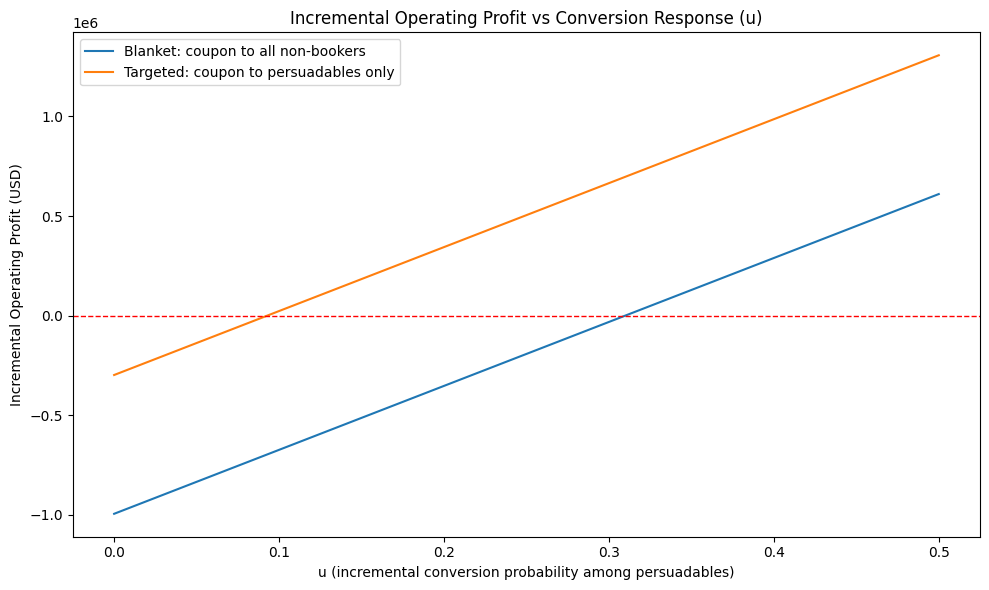

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) Inputs from your data
# =========================
booked_ratio = raw_df['is_booked'].mean()
r_nb = 1 - booked_ratio
N_total = len(raw_df)
N_nb = N_total * r_nb

# =========================
# 1) Scenario assumptions
# =========================
p_persu = 0.30
m = 86.0
c = 8.0

# =========================
# 2) Sweep uplift
# =========================
u = np.linspace(0.0, 0.5, 251)

# =========================
# 3) Profit models
# =========================
profit_blanket = N_nb * (p_persu * u * m - c)
profit_targeted = N_nb * (p_persu * (u * m - c))

# =========================
# 4) Plot (ONLY first graph)
# =========================
plt.figure(figsize=(10, 6))
plt.plot(u, profit_blanket, label='Blanket: coupon to all non-bookers')
plt.plot(u, profit_targeted, label='Targeted: coupon to persuadables only')

# 0-profit line (red dashed)
plt.axhline(0, linestyle='--', color='red', linewidth=1)

plt.title('Incremental Operating Profit vs Conversion Response (u)')
plt.xlabel('u (incremental conversion probability among persuadables)')
plt.ylabel('Incremental Operating Profit (USD)')
plt.legend()
plt.tight_layout()
plt.show()

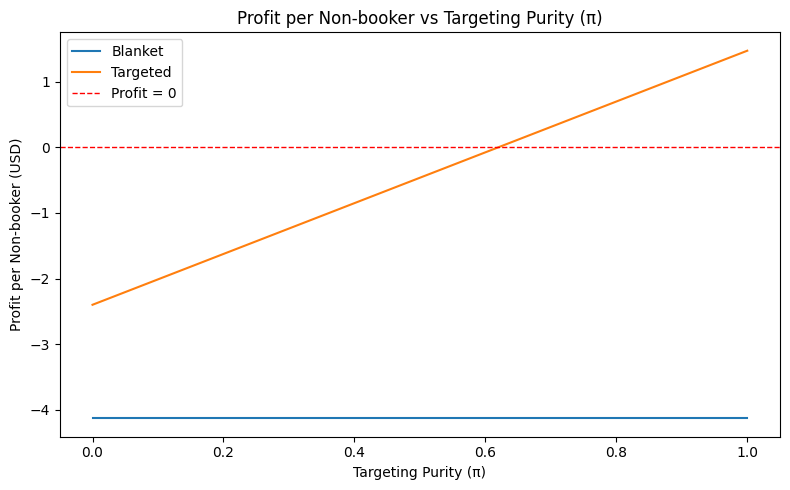

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Assumptions (edit if needed)
# =========================
p = 0.30     # persuadable share among non-bookers
q = 0.30     # targeting size
m = 86.0     # margin per incremental booking (USD)
c = 8.0      # expected coupon cost per treated user (USD)
u = 0.15     # fixed uplift among persuadables

# Targeting purity range
pi = np.linspace(0.0, 1.0, 251)

# Profit per non-booker
profit_blanket = p * u * m - c
profit_targeted = q * (pi * u * m - c)

# =========================
# Plot
# =========================
plt.figure(figsize=(8, 5))
plt.plot(pi, np.repeat(profit_blanket, len(pi)), label='Blanket')
plt.plot(pi, profit_targeted, label='Targeted')

# 0-profit horizontal line (red dashed)
plt.axhline(0, linestyle='--', color='red', linewidth=1, label='Profit = 0')

plt.title('Profit per Non-booker vs Targeting Purity (π)')
plt.xlabel('Targeting Purity (π)')
plt.ylabel('Profit per Non-booker (USD)')
plt.legend()
plt.tight_layout()
plt.show()